# 12 · Random Forest + Kriging

Template para `RegressionKrigingModel`, separando claramente la parte no lineal del bosque y el ajuste espacial sobre residuos.

## Hipótesis del modelo

- El Random Forest captura relaciones no lineales y umbrales.
- El kriging sobre residuos agrega estructura espacial que el bosque no explica por sí solo.
- La interpretación puede combinar importancia global de features con mapas de residuo antes y después del kriging.

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
from pathlib import Path
import sys
import pandas as pd
import geopandas as gpd
import seaborn as sns
import numpy as np


PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from ml_core.models.rfrkModel import RegressionKrigingModel
from ml_core.evaluation.modelEvaluator import regression_metrics
from ml_core.visualization.mapper import generar_grid_predicciones,MapaPrecio,ZTestMapVisualizer,CombinedZLisaMapVisualizer
from ml_core import load_model_config, save_model_config
from ml_core.outlierAnalysis.oof import (
    detect_outliers_oof,
    load_active_processed_geodata,
)
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "12_rf_kriging"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

## Datos y configuración

In [3]:
DATA_PATH = PROJECT_ROOT / "data" / "splits"

train_raw = pd.read_csv(DATA_PATH / "arg_venta_data_train.csv")
gdf_train = gpd.GeoDataFrame(
    train_raw,
    geometry=gpd.points_from_xy(
        train_raw["longitud"],
        train_raw["latitud"]
    ),
    crs="EPSG:4326"
)

test_raw = pd.read_csv(DATA_PATH / "arg_venta_data_test.csv")
gdf_test = gpd.GeoDataFrame(
    test_raw,
    geometry=gpd.points_from_xy(
        test_raw["longitud"],
        test_raw["latitud"]
    ),
    crs="EPSG:4326"
)

val_raw = pd.read_csv(DATA_PATH / "arg_venta_data_val.csv")
gdf_val = gpd.GeoDataFrame(
    val_raw,
    geometry=gpd.points_from_xy(
        val_raw["longitud"],
        val_raw["latitud"]
    ),
    crs="EPSG:4326"
)



target_col = "log_precio"   
coord_cols = ["longitud", "latitud"]
feature_cols = [
    'area_m2_total',
    'area_m2_descubierta',
    'ambientes',
    'antiguedad',
    'expensas',
    'banos',
    'cocheras',
    'estado_num',
    'disposicion_Frente',
    'disposicion_Contrafrente',
    'disposicion_Lateral',
    'dist_subte',
    'dist_universidad',
    'dist_hospital',
    'dist_est_educativo',
    'dist_espacio_verde',
    'dist_areas_programaticas',
    'dist_avenida_rivadavia',
    "n_robos_1000m",
    "n_universidades_1000m",
    "pozo",
    "velocidad_ventas_1000m_90d"
]



/tmp/ipykernel_6642/882242239.py:13: DtypeWarning: Columns (0: orientacion, 1: fecha_orde, 2: fecha_bole) have mixed types. Specify dtype option on import or set low_memory=False.
  test_raw = pd.read_csv(DATA_PATH / "arg_venta_data_test.csv")
/tmp/ipykernel_6642/882242239.py:23: DtypeWarning: Columns (0: tipo_unidad, 1: orientacion, 2: fecha_orde, 3: fecha_bole) have mixed types. Specify dtype option on import or set low_memory=False.
  val_raw = pd.read_csv(DATA_PATH / "arg_venta_data_val.csv")


In [4]:
X_train = gdf_train[feature_cols]
y_train = gdf_train[target_col]
coords_train = gdf_train[coord_cols].to_numpy()

X_test = gdf_test[feature_cols]
y_test = gdf_test[target_col]
coords_test = gdf_test[coord_cols].to_numpy()

X_val = gdf_val[feature_cols]
y_val = gdf_val[target_col]
coords_val = gdf_val[coord_cols].to_numpy()

## Entrenamiento

In [5]:
rf_params = {
    "n_estimators": 500,
    "max_depth": None,
    "min_samples_leaf": 3,
    "max_features": "log2",
}

kriging_params = {
    "n_closest_points": 7,
    "variogram_model": "linear",
    "pseudo_inv": True,
    "pseudo_inv_type": "pinvh",
}

model = RegressionKrigingModel(rf_params=rf_params, kriging_params=kriging_params, use_kriging=False)
model.fit(X_train, y_train, coords_train)
model


In [6]:


config_path = Path("notebooks/cache/rfrk_best_config.json")
saved_config = load_model_config(config_path)

if saved_config is None:
    model = RegressionKrigingModel(
        rf_params=rf_params,
        kriging_params=kriging_params,
        use_kriging=False,
    )
    model.tune_hyperparameters(X_test, y_test.values.ravel(), coords_test)

    save_model_config(
        model,
        config_path,
        extra={"target": target_col, "features": feature_cols},
    )

    saved_config = load_model_config(config_path)

rf_params = saved_config.get("rf_params", {})
kriging_params = saved_config.get("kriging_params", {})

best_config = {"RegressionKriging_params": rf_params, "kriging_params": kriging_params, "selected_k": getattr(model, "kriging_params_", {}).get("n_closest_points", None)}
best_config


{'RegressionKriging_params': {'n_estimators': 500,
  'max_depth': None,
  'min_samples_leaf': 1,
  'max_features': 0.5,
  'bootstrap': True,
  'min_samples_split': 2},
 'kriging_params': {'n_closest_points': 7,
  'variogram_model': 'linear',
  'pseudo_inv': True,
  'pseudo_inv_type': 'pinvh'},
 'selected_k': None}

## Tuning tentativo

Acá podés barrer hiperparámetros del bosque y del kriging, o hacer primero tuning del RF y después del componente espacial.

## Evaluación global

In [7]:
rf_params = best_config["RegressionKriging_params"]
kriging_params = best_config["kriging_params"]
model = RegressionKrigingModel(rf_params=rf_params, kriging_params=kriging_params, use_kriging=False)
model.fit(X_train, y_train, coords_train)
model

y_pred_log = model.predict(
    X_val,
    coords_val
)

# revertir log
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_val)

metrics = regression_metrics(
    y_true,
    y_pred
)

metrics

{'rmse': 36510.28653748511,
 'mae': 16734.432897509112,
 'r2': 0.9163028952607607,
 'bias': 4563.5160750904015,
 'median_abs_error': 7272.331077832052,
 'mape': 10.20798568528076}

## Visualización


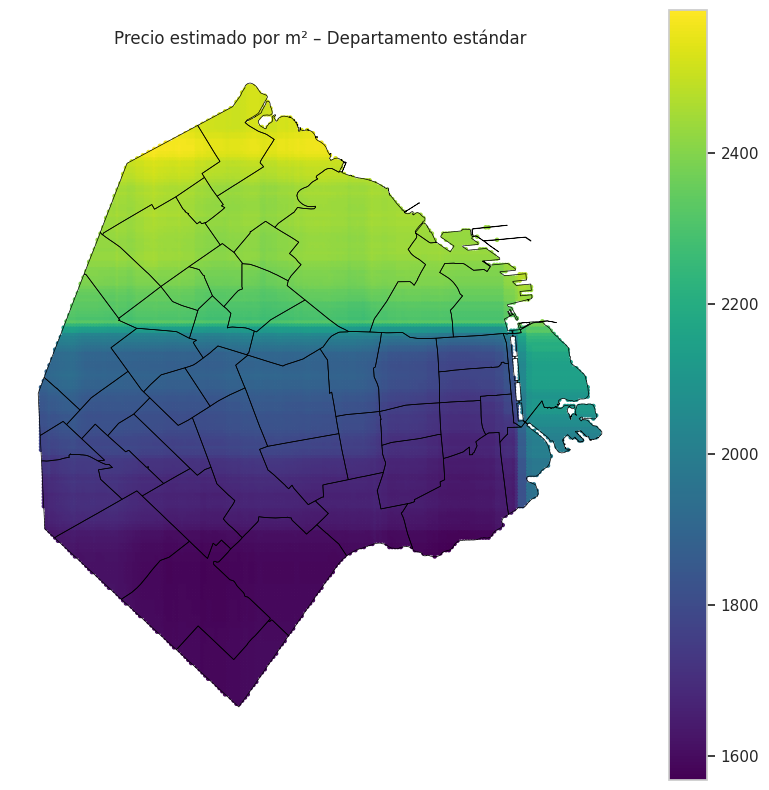

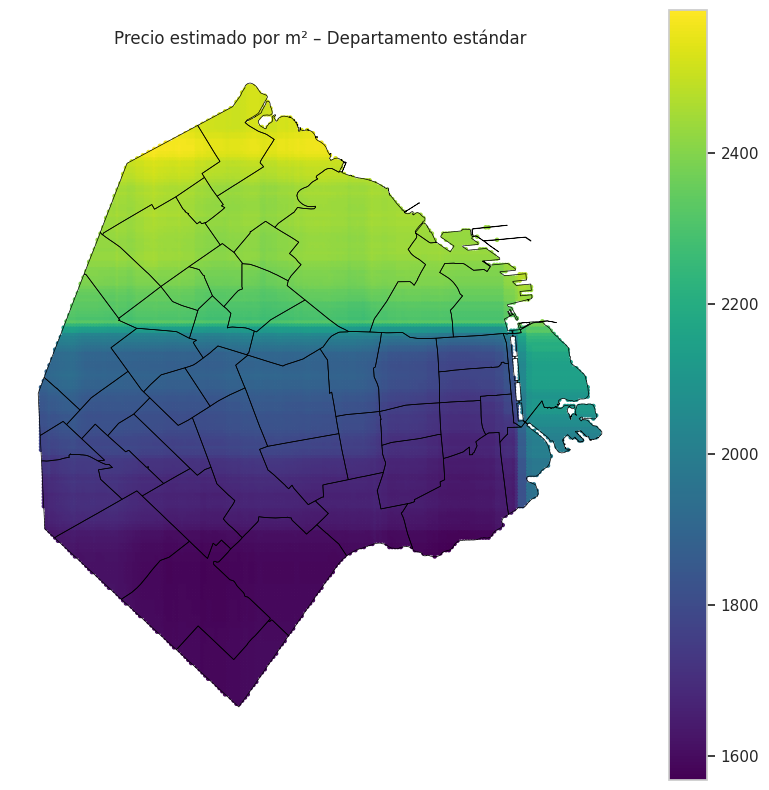

In [8]:
barrios_path = PROJECT_ROOT / 'GeoData' / 'barrios.geojson'

df_grid, barrios, std = generar_grid_predicciones(
    model,
    gdf_val,
    feature_cols
)

mapa = MapaPrecio(df_grid, barrios)

mapa.plot()

#mapa.save("mapa_modelo_lgwr.png")

#mapa.save("mapa_modelo_lgwr.pdf")



## Interpretación del Random Forest

In [13]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_(),
}).sort_values("importance", ascending=False)
feature_importance

,feature,importance
2,ambientes,0.349367
0,area_m2_total,0.331625
3,antiguedad,0.201334
4,expensas,0.164337
13,dist_hospital,0.094568
17,dist_avenida_rivadavia,0.054198
14,dist_est_educativo,0.051802
12,dist_universidad,0.046599
18,n_robos_1000m,0.042118
11,dist_subte,0.038917


## Residuo del bosque vs residuo final

Si querés entender el aporte del kriging, compará explícitamente el error del RF puro contra el error final del modelo combinado.

Oportunity detector?

In [15]:


rf_params = best_config["RegressionKriging_params"]
kriging_params = best_config["kriging_params"]


def build_rfrk_model():
    return RegressionKrigingModel(
        rf_params=rf_params,
        kriging_params=kriging_params,
        use_kriging=False,
    )


DATA_PATH = PROJECT_ROOT / "data" / "processed"

gdf_all = load_active_processed_geodata(
    data_path=DATA_PATH / "arg_venta_data_processed.csv",
    feature_cols=feature_cols,
    target_col=target_col,
    coord_cols=coord_cols,
    extra_cols=["idx", "url", "precio"],
)

X_all = gdf_all[feature_cols]
y_all = gdf_all[target_col]
coords_all = gdf_all[coord_cols].to_numpy()

results_by_method, residuals_oof = detect_outliers_oof(
    model_factory=build_rfrk_model,
    X=X_all,
    y=y_all,
    gdf=gdf_all,
    coords=coords_all,
    output_dir=OUTPUT_DIR / "outliers_oof",
    methods=["ztest","combined_z_lisa"],
    params_for_methods={
        "ztest": {"alpha": 0.05}
                },
    k_neighbors=15,
    n_splits=5,
)




Fold 1/5

Fold 2/5

Fold 3/5

Fold 4/5

Fold 5/5


## Mapa de Residuos

Graficamos un mapa con los residuos para observar las zonas con más error de predicción.

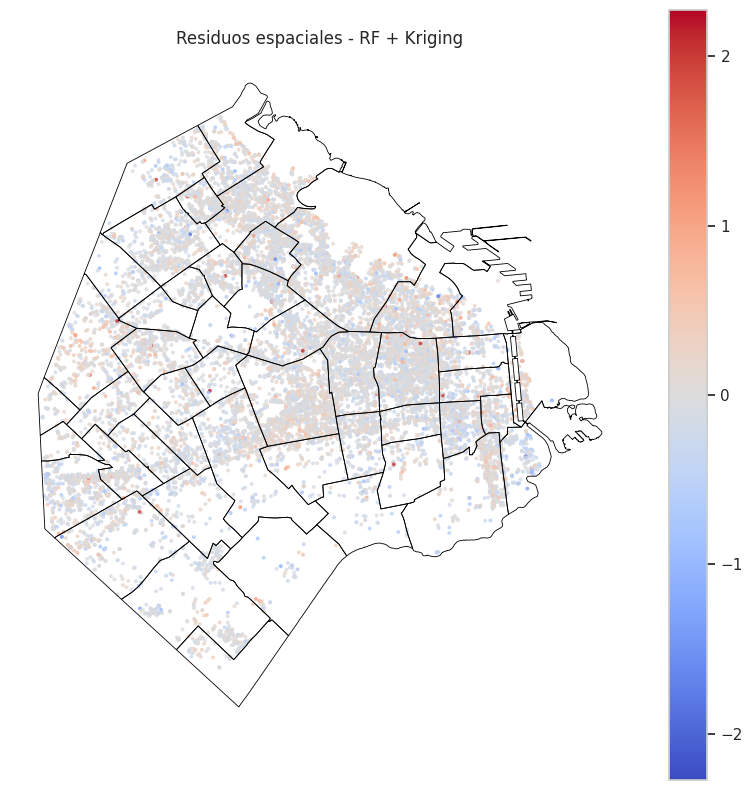

In [19]:


import geopandas as gpd
from ml_core.visualization.mapper import plot_residuals_map
gdf_res = gdf_all.copy()
gdf_res["residual"] = residuals_oof

fig, ax = plot_residuals_map(
    gdf=gdf_res,
    residual_col="residual",
    boundary_path=barrios_path,
    title="Residuos espaciales - RF + Kriging",
)


## Mapa interactivo de atipicidad (`ztest`)

Visualización de todos los avisos activos en CABA. Los avisos detectados como más atípicos según `ztest` aparecen con color más intenso; los no atípicos quedan en gris.


In [20]:
from IPython.display import IFrame, display

combined_z_lisa_visualizer = CombinedZLisaMapVisualizer(
    gdf_all=gdf_all,
    results_df=results_by_method["combined_z_lisa"],
    barrios_path=PROJECT_ROOT / "GeoData" / "barrios.geojson"
)
combined_z_lisa_map = combined_z_lisa_visualizer.build_map()
combined_z_lisa_map_path = OUTPUT_DIR / "outliers_oof" / "combined_z_lisa_interactive_map.html"
combined_z_lisa_visualizer.save_map(combined_z_lisa_map_path)
display(IFrame(src=str(combined_z_lisa_map_path.relative_to(PROJECT_ROOT)), width="100%", height=700))


In [22]:
from IPython.display import IFrame, display

ztest_visualizer = ZTestMapVisualizer(
    gdf_all=gdf_all,
    results_df=results_by_method["ztest"],
    barrios_path=PROJECT_ROOT / "GeoData" / "barrios.geojson"
)
ztest_map = ztest_visualizer.build_map()
ztest_map_path = OUTPUT_DIR / "outliers_oof" / "ztest_interactive_map.html"
ztest_visualizer.save_map(ztest_map_path)
display(IFrame(src=str(ztest_map_path.relative_to(PROJECT_ROOT)), width="100%", height=700))
